<a href="https://colab.research.google.com/github/Mohamed-yousef-hafez/Outliers-outliers_implemetation.ipynb/blob/main/Outliers_outliers_implemetation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("NHANES Weight and Height.csv")

In [3]:
df.head()

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
0,0,97.1,160.2,37.8
1,1,98.8,182.3,29.7
2,2,74.3,184.2,21.9
3,3,103.7,185.3,30.2
4,4,83.3,177.1,26.6


In [4]:
df.shape

(8388, 4)

In [5]:
df.columns

Index(['Unnamed: 0', 'Weight (kg)', 'Standing Height (cm)', 'BMI(kg/m**2)'], dtype='object')

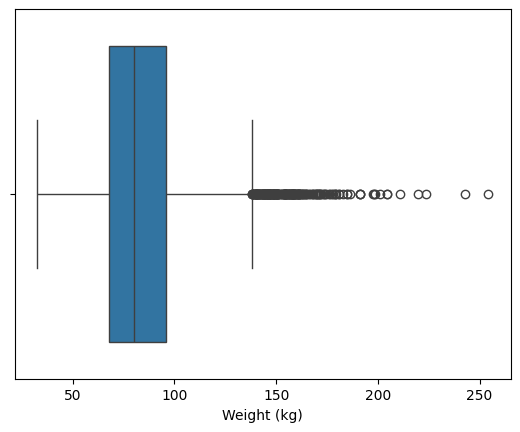

In [6]:
sns.boxplot(data = df, x = "Weight (kg)")
plt.show()


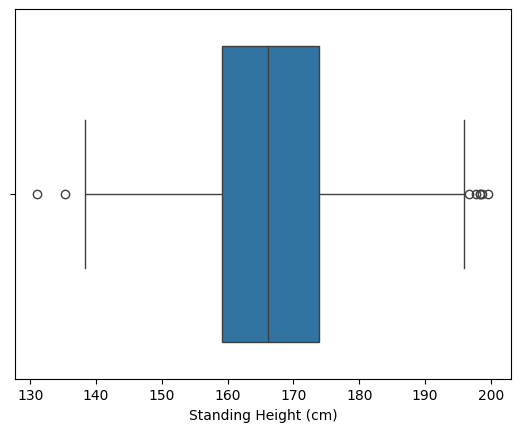

In [7]:
sns.boxplot(data = df, x = "Standing Height (cm)")
plt.show()

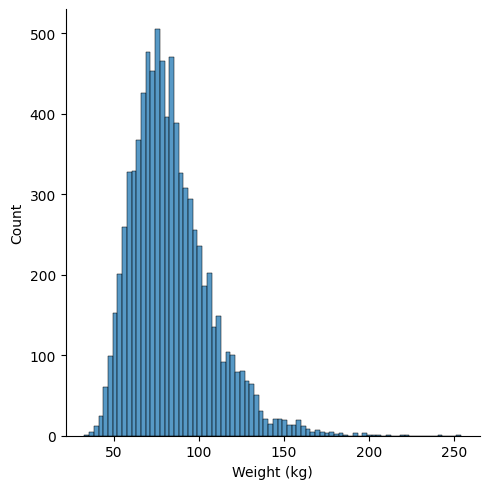

In [8]:
sns.displot(data = df, x = "Weight (kg)", kind = "hist")
plt.show()

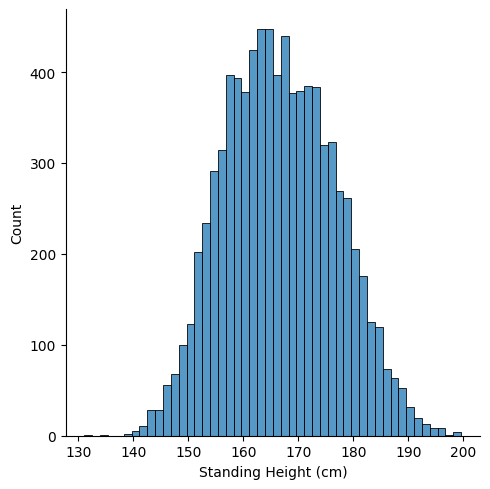

In [9]:
sns.displot(data = df, x = "Standing Height (cm)", kind = "hist")
plt.show()

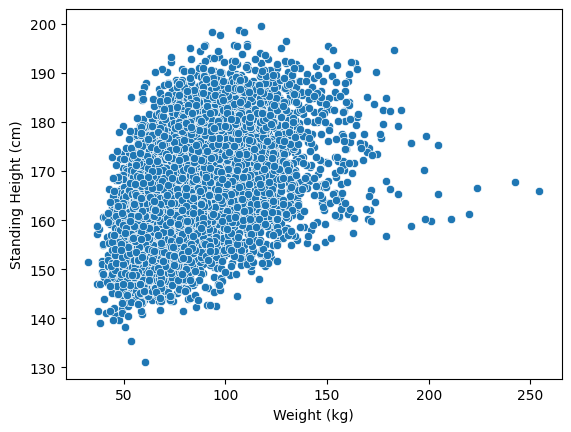

In [10]:
sns.scatterplot(data = df, x = "Weight (kg)", y = "Standing Height (cm)")
plt.show()

2. Statistical methods
Z-Score (Normally distributed data)
IQR (Interquartile Range) - Skewed data

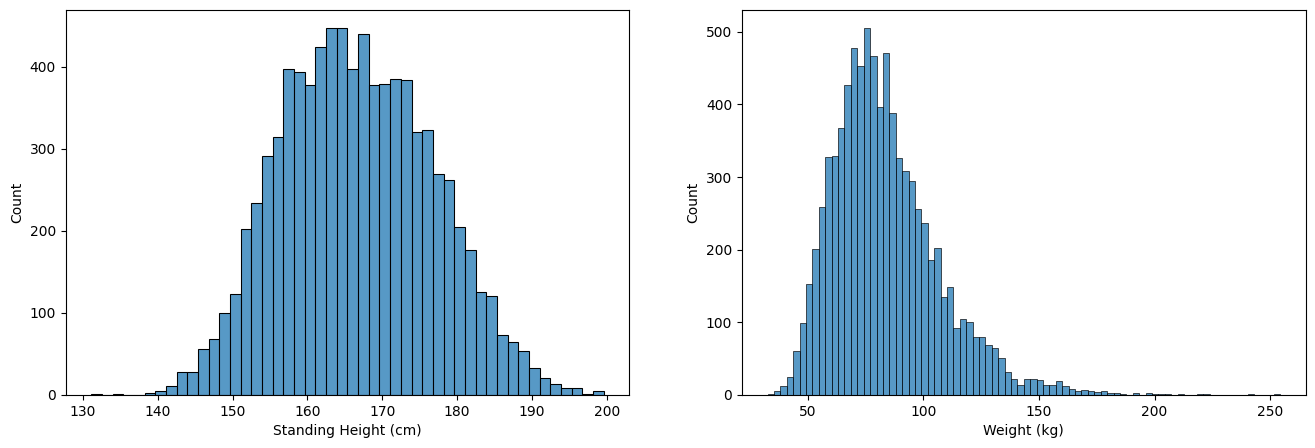

In [11]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['Standing Height (cm)'])

plt.subplot(1,2,2)
sns.histplot(df['Weight (kg)'])

plt.show()

In [12]:
df.skew()

,0
Unnamed: 0,0.000000
Weight (kg),1.129603
Standing Height (cm),0.142496
BMI(kg/m**2),1.353043


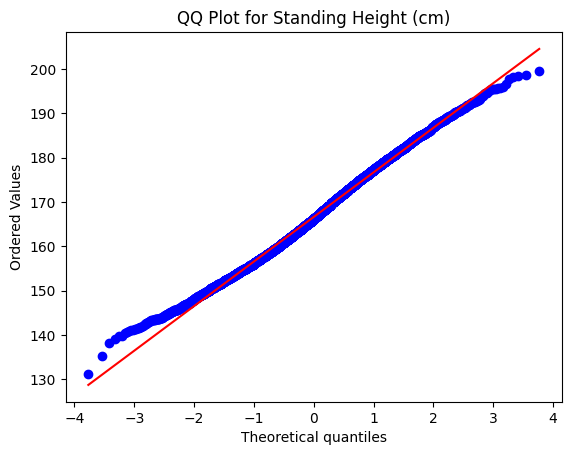

In [13]:
stats.probplot(df['Standing Height (cm)'], dist="norm", plot=plt)
plt.title("QQ Plot for Standing Height (cm)")
plt.show()

Z-Score
How many standard deviations a data point is away from the mean

z = (x - μ) / σ

x = μ + zσ

If datapoint is 3 standard deviations away from mean, consider it as outlier

In [14]:
zscore_height = stats.zscore(df["Standing Height (cm)"])
zscore_height

array([-0.63910757,  1.55369806,  1.74221981, ...,  0.20427921,
        0.96828842,  0.08521284])

In [15]:
df1 = df.copy()

In [16]:
df1["Z Score Height"] = zscore_height
df1

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2),Z Score Height
0,0,97.1,160.2,37.8,-0.639108
1,1,98.8,182.3,29.7,1.553698
2,2,74.3,184.2,21.9,1.742220
3,3,103.7,185.3,30.2,1.851364
4,4,83.3,177.1,26.6,1.037744
...,...,...,...,...,...
8383,8383,94.3,178.8,29.5,1.206421
8384,8384,82.8,147.8,37.9,-1.869460
8385,8385,108.8,168.7,38.2,0.204279
8386,8386,79.5,176.4,25.5,0.968288


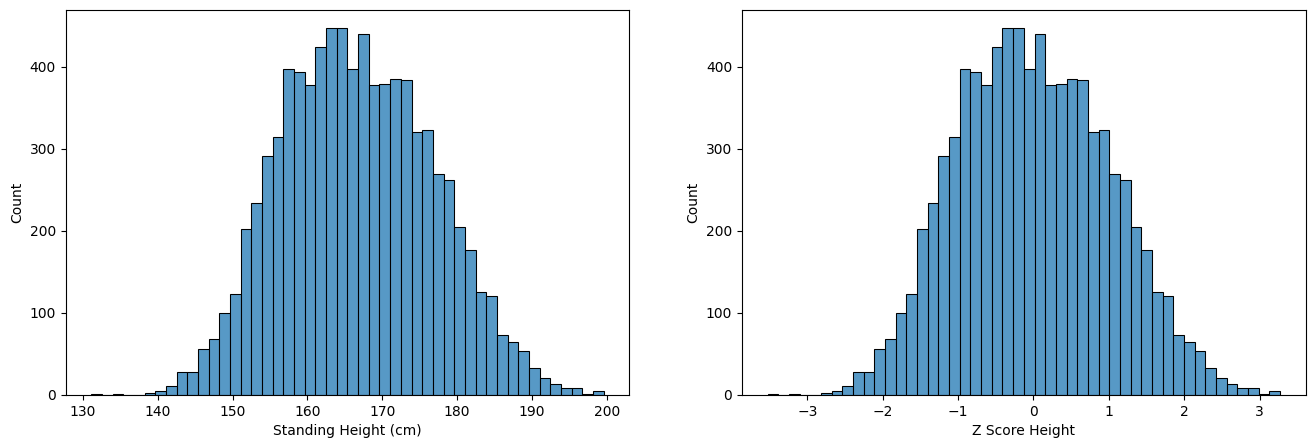

In [17]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df1['Standing Height (cm)'])

plt.subplot(1,2,2)
sns.histplot(df1['Z Score Height'])

plt.show()

In [18]:
(zscore_height < -3) | (zscore_height > 3)

array([False, False, False, ..., False, False, False])

In [19]:
df1[(zscore_height < -3) | (zscore_height > 3)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2),Z Score Height
60,60,106.8,198.7,27.1,3.180938
1906,1906,53.8,135.3,29.4,-3.109735
2165,2165,60.3,131.1,35.1,-3.526467
3379,3379,97.5,197.7,24.9,3.081716
4026,4026,93.6,198.4,23.8,3.151172
5815,5815,109.1,198.3,27.7,3.141250
7576,7576,117.4,199.6,29.5,3.270238


In [20]:
# x = mean + z * std
# x_lower = mean - 3 * std
# x_upper = mean + 3 * std
x_lower = df["Standing Height (cm)"].mean() - 3 * df["Standing Height (cm)"].std()
x_upper = df["Standing Height (cm)"].mean() + 3 * df["Standing Height (cm)"].std()
x_lower, x_upper

(np.float64(136.40414941422722), np.float64(196.87823017566313))

In [21]:
(df["Standing Height (cm)"]<x_lower) | (df["Standing Height (cm)"]>x_upper)

,Standing Height (cm)
0,False
1,False
2,False
3,False
4,False
...,...
8383,False
8384,False
8385,False
8386,False


In [22]:
df[(df["Standing Height (cm)"]<x_lower) | (df["Standing Height (cm)"]>x_upper)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
60,60,106.8,198.7,27.1
1906,1906,53.8,135.3,29.4
2165,2165,60.3,131.1,35.1
3379,3379,97.5,197.7,24.9
4026,4026,93.6,198.4,23.8
5815,5815,109.1,198.3,27.7
7576,7576,117.4,199.6,29.5


IQR (Interquartile Range) - Skewed data
1. Calculate the IQR: The interquartile range is the difference between the third 2. quartile (Q3) and the first 3. quartile (Q1) of the data.
4. Determine the outlier --

--boundaries:
minimum: Q1 - (1.5 * IQR)
maximum: Q3 + (1.5 * IQR)
Identify outliers: Any data point below the lower bound or above the upper bound is considered an outlier.

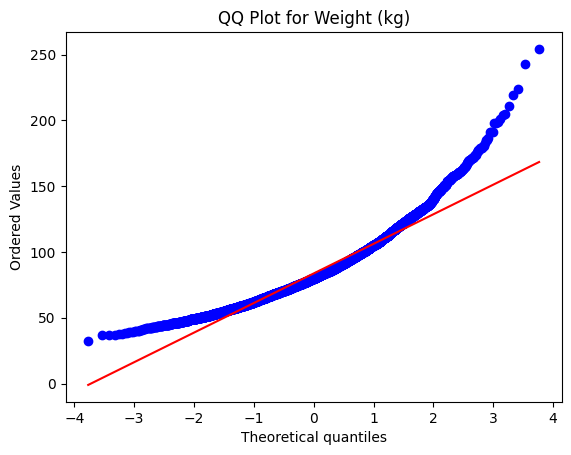

In [23]:
stats.probplot(df['Weight (kg)'], dist="norm", plot=plt)
plt.title("QQ Plot for Weight (kg)")
plt.show()

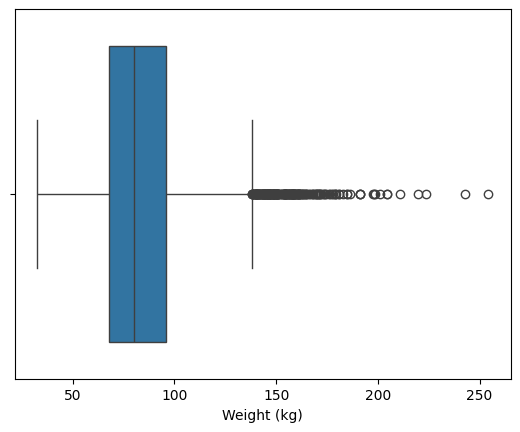

In [24]:
sns.boxplot(data= df, x = "Weight (kg)")
plt.show()

In [25]:
q1 = df["Weight (kg)"].quantile(0.25)
q3 = df["Weight (kg)"].quantile(0.75)
iqr = q3-q1

In [26]:
q1,q3,iqr

(np.float64(67.6), np.float64(95.8), np.float64(28.200000000000003))

In [27]:
minimum = q1 - 1.5*iqr
maximum = q3 + 1.5*iqr
minimum, maximum

(np.float64(25.29999999999999), np.float64(138.1))

In [28]:
(df["Weight (kg)"] < minimum) | (df["Weight (kg)"] > maximum)

,Weight (kg)
0,False
1,False
2,False
3,False
4,False
...,...
8383,False
8384,False
8385,False
8386,False


In [29]:
df[(df["Weight (kg)"] < minimum) | (df["Weight (kg)"] > maximum)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
34,34,138.2,172.9,46.2
36,36,138.7,158.7,55.1
86,86,143.4,182.0,43.3
94,94,191.4,175.8,61.9
100,100,140.4,175.9,45.4
...,...,...,...,...
8170,8170,166.6,174.7,54.6
8204,8204,143.7,185.4,41.8
8233,8233,173.0,183.6,51.3
8328,8328,144.6,172.8,48.4


1. Remove Outliers (trimming)

In [30]:
# Zcores
zscore_height

array([-0.63910757,  1.55369806,  1.74221981, ...,  0.20427921,
        0.96828842,  0.08521284])

In [31]:
(zscore_height < -3) | (zscore_height > 3)

array([False, False, False, ..., False, False, False])

In [32]:
(zscore_height >= -3) & (zscore_height <= 3)

array([ True,  True,  True, ...,  True,  True,  True])

In [33]:
df[(zscore_height >= -3) & (zscore_height <= 3)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
0,0,97.1,160.2,37.8
1,1,98.8,182.3,29.7
2,2,74.3,184.2,21.9
3,3,103.7,185.3,30.2
4,4,83.3,177.1,26.6
...,...,...,...,...
8383,8383,94.3,178.8,29.5
8384,8384,82.8,147.8,37.9
8385,8385,108.8,168.7,38.2
8386,8386,79.5,176.4,25.5


In [34]:
# iqr
minimum, maximum


(np.float64(25.29999999999999), np.float64(138.1))

In [35]:
df.columns

Index(['Unnamed: 0', 'Weight (kg)', 'Standing Height (cm)', 'BMI(kg/m**2)'], dtype='object')

In [36]:
df[(df["Weight (kg)"]<minimum) | (df["Weight (kg)"]>maximum)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
34,34,138.2,172.9,46.2
36,36,138.7,158.7,55.1
86,86,143.4,182.0,43.3
94,94,191.4,175.8,61.9
100,100,140.4,175.9,45.4
...,...,...,...,...
8170,8170,166.6,174.7,54.6
8204,8204,143.7,185.4,41.8
8233,8233,173.0,183.6,51.3
8328,8328,144.6,172.8,48.4


In [37]:
df2 = df[(df["Weight (kg)"]>=minimum) & (df["Weight (kg)"]<=maximum)]

In [38]:
df2[(df2["Weight (kg)"]<minimum) | (df2["Weight (kg)"]>maximum)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)


In [39]:
df2

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
0,0,97.1,160.2,37.8
1,1,98.8,182.3,29.7
2,2,74.3,184.2,21.9
3,3,103.7,185.3,30.2
4,4,83.3,177.1,26.6
...,...,...,...,...
8383,8383,94.3,178.8,29.5
8384,8384,82.8,147.8,37.9
8385,8385,108.8,168.7,38.2
8386,8386,79.5,176.4,25.5


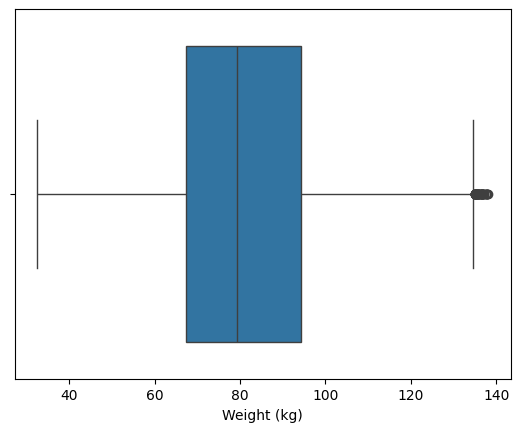

In [40]:
sns.boxplot(data = df2, x = "Weight (kg)")
plt.show()

2. Cap/Floor (Winsorization)

In [41]:
# IQR
minimum, maximum

(np.float64(25.29999999999999), np.float64(138.1))

In [42]:
df3 = df.copy()

In [43]:
df3["Weight (kg)"] = df3["Weight (kg)"].clip(lower = minimum, upper = maximum)

In [44]:
df3[(df3['Weight (kg)'] > maximum) | (df3['Weight (kg)'] < minimum)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)


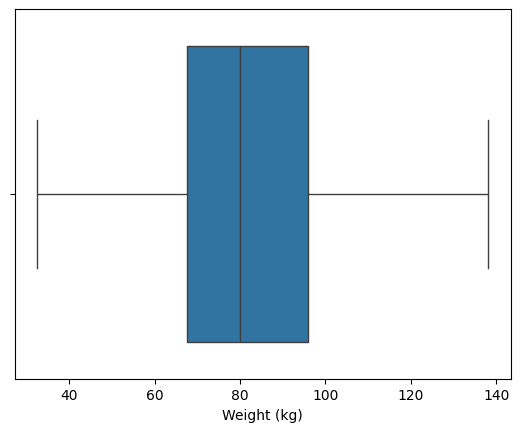

In [45]:
sns.boxplot(data = df3, x = "Weight (kg)")
plt.show()

In [46]:
# Zscore
x_lower, x_upper

(np.float64(136.40414941422722), np.float64(196.87823017566313))

In [47]:
df4 = df.copy()
df4["Standing Height (cm)"] = df4['Standing Height (cm)'].clip(lower=x_lower, upper=x_upper)

In [48]:
df4[(df4['Standing Height (cm)'] > x_upper) | (df4['Standing Height (cm)'] < x_lower)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)


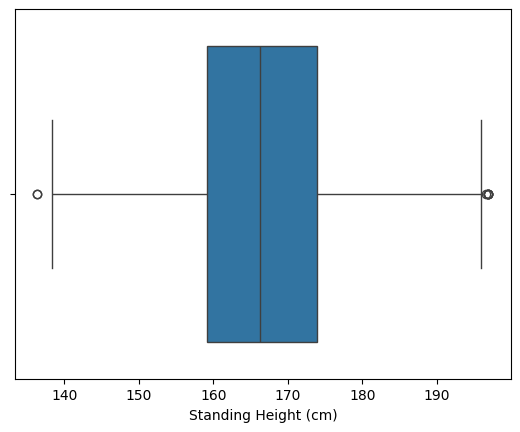

In [49]:
sns.boxplot(data = df4, x = "Standing Height (cm)")
plt.show()


In [50]:
# winsorization (percentile)
df5 = df.copy()
lower_percentile = df5["Weight (kg)"].quantile(0.02)
upper_percentile = df5["Weight (kg)"].quantile(0.98)
lower_percentile, upper_percentile

(np.float64(48.7), np.float64(143.72600000000003))

In [51]:
df5["Weight (kg)"] = df5["Weight (kg)"].clip(lower = lower_percentile, upper = upper_percentile)

3. Imputation

In [52]:
df6 = df.copy()

In [53]:
# IQR
minimum, maximum

(np.float64(25.29999999999999), np.float64(138.1))

In [54]:
median = df6["Weight (kg)"].median()
median

79.9

In [55]:
df6[(df6["Weight (kg)"] < minimum) | (df6["Weight (kg)"] > maximum)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
34,34,138.2,172.9,46.2
36,36,138.7,158.7,55.1
86,86,143.4,182.0,43.3
94,94,191.4,175.8,61.9
100,100,140.4,175.9,45.4
...,...,...,...,...
8170,8170,166.6,174.7,54.6
8204,8204,143.7,185.4,41.8
8233,8233,173.0,183.6,51.3
8328,8328,144.6,172.8,48.4


In [56]:
df6.loc[(df6["Weight (kg)"] < minimum) | (df6["Weight (kg)"] > maximum), "Weight (kg)"] = median

In [57]:
df6[(df6['Weight (kg)'] > maximum) | (df6['Weight (kg)'] < minimum)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)


4. Data Transformation
- log transformation - log(x)
- sqaure root transformation - sqrt(x)
- reciprocal transformation - (1/x)
- power transformation - BoxCox transformation

In [58]:
df7 = df.copy()
df7["Weight (kg)"]


,Weight (kg)
0,97.1
1,98.8
2,74.3
3,103.7
4,83.3
...,...
8383,94.3
8384,82.8
8385,108.8
8386,79.5


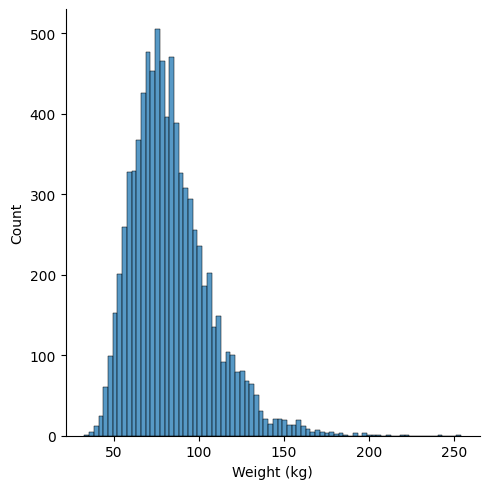

In [59]:
sns.displot(df7["Weight (kg)"])
plt.show()


In [60]:
df7["Weight (kg)"] = np.log(df7["Weight (kg)"])

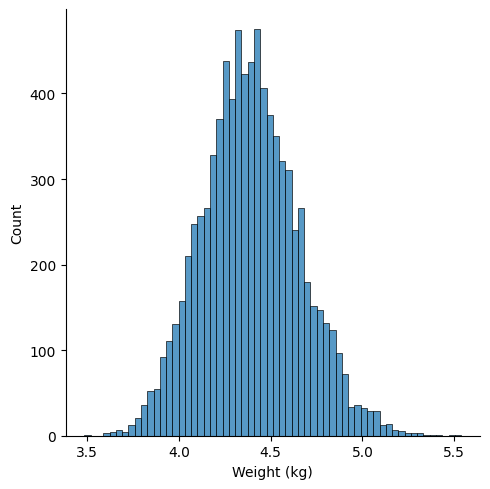

In [61]:
sns.displot(df7["Weight (kg)"])
plt.show()